# P-ML12a — Cross-Asset Comovement Research

**Motivation:** P-ML11 demonstrated that BTC-only features cannot solve the Fold 2
ATH+crash timing problem. The model needs *exogenous* information — signals from
traditional financial markets that reflect macro regime changes, institutional
rebalancing, and liquidity conditions.

**This is research-first:** understand *why* and *when* cross-asset correlations
exist before deciding what features to engineer.

**Key questions:**
1. How has BTC's correlation with equities, gold, bonds, and USD evolved over eras?
2. Is there a lead-lag relationship (do equity moves predict BTC)?
3. Do volume spikes in one market predict moves in another?
4. How do correlations change during stress events vs calm periods?
5. Did institutional adoption structurally change the correlation regime?

**Assets studied:**
- **SPY** (S&P 500) — broad equity market risk appetite
- **QQQ** (Nasdaq-100) — tech/growth sentiment, closest to crypto investor base
- **GLD** (Gold ETF) — store-of-value narrative, inflation hedge
- **TLT** (20+ Year Treasuries) — rate sensitivity, risk-free alternative
- **UUP** (USD Index ETF) — dollar strength, global liquidity proxy
- **^VIX** (CBOE Volatility Index) — fear gauge, tail risk indicator

**Era definitions:**
| Era | Period | Rationale |
|---|---|---|
| Era 1: Retail | 2019-01 to 2020-03 | Pre-COVID, crypto = niche retail asset |
| Era 2: COVID | 2020-03 to 2021-01 | Pandemic crash + recovery, fiscal stimulus |
| Era 3: Institutional | 2021-01 to 2022-01 | Tesla/MicroStrategy buys, Coinbase IPO, Fold 2 period |
| Era 4: Bear | 2022-01 to 2024-01 | Fed tightening, Luna/FTX, crypto winter |
| Era 5: ETF | 2024-01 to 2025-01 | BTC spot ETF approval, institutional inflows |

## §1 — Config & Data Loading

In [1]:
import sys
from pathlib import Path
repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from collections import OrderedDict

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 9})

# -- Config --------------------------------------------------------------------
SINCE, UNTIL = "2019-01-01", "2025-01-01"
TICKERS = ["SPY", "QQQ", "GLD", "TLT", "UUP"]
VIX     = "^VIX"
ALL_TF  = TICKERS + [VIX]

ERAS = OrderedDict([
    ("Era1 Retail\n(2019-2020.03)",    ("2019-01-01", "2020-03-01")),
    ("Era2 COVID\n(2020.03-2021.01)",  ("2020-03-01", "2021-01-01")),
    ("Era3 Institutional\n(2021)",     ("2021-01-01", "2022-01-01")),
    ("Era4 Bear\n(2022-2024)",         ("2022-01-01", "2024-01-01")),
    ("Era5 ETF\n(2024+)",             ("2024-01-01", "2025-01-01")),
])

ERA_COLORS = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#e67e22"]

# -- Load data -----------------------------------------------------------------
from data.fetch import fetch_ohlcv
from data.cross_asset import fetch_tradfi_ohlcv, align_to_common_dates

btc_raw = fetch_ohlcv(symbol="BTC/USDT", timeframe="1d", since=SINCE, until=UNTIL)
print(f"BTC: {len(btc_raw)} bars ({btc_raw.index[0].date()} -> {btc_raw.index[-1].date()})")

tradfi = {}
for t in ALL_TF:
    tradfi[t] = fetch_tradfi_ohlcv(t, since=SINCE, until=UNTIL)
    print(f"{t:>5}: {len(tradfi[t])} bars")

# -- Align to common trading dates --------------------------------------------
panel, common_idx = align_to_common_dates(btc_raw, tradfi)

# Strip timezone from all indexes for consistent comparison
common_idx = common_idx.tz_localize(None) if common_idx.tz else common_idx
panel.index = panel.index.tz_localize(None) if panel.index.tz else panel.index

btc_pct_lost = 1 - len(common_idx) / len(btc_raw)
print(f"\nCommon dates: {len(common_idx)} ({common_idx[0].date()} -> {common_idx[-1].date()})")
print(f"BTC bars lost to weekend alignment: {btc_pct_lost:.1%}")

# -- Compute log returns -------------------------------------------------------
rets = pd.DataFrame(index=common_idx)
for name in ["BTC"] + TICKERS + [VIX]:
    rets[name] = np.log(panel[(name, "close")] / panel[(name, "close")].shift(1))
rets = rets.iloc[1:]  # drop first NaN row

# -- Compute volume series (normalized to 20-day mean) -------------------------
vols = pd.DataFrame(index=common_idx)
for name in ["BTC"] + TICKERS:
    raw_vol = panel[(name, "volume")]
    vols[name] = raw_vol / raw_vol.rolling(20, min_periods=1).mean()
vols = vols.iloc[1:]

# -- Helper: era mask (tz-naive comparison) ------------------------------------
def era_mask(index, start, end):
    """Boolean mask for [start, end) date range."""
    return (index >= pd.Timestamp(start)) & (index < pd.Timestamp(end))

print(f"\nReturn matrix: {rets.shape}, Volume matrix: {vols.shape}")

BTC: 1097 bars (2022-01-01 -> 2025-01-01)
  SPY: 1510 bars
  QQQ: 1510 bars
  GLD: 1510 bars
  TLT: 1510 bars
  UUP: 1510 bars
 ^VIX: 1510 bars

Common dates: 753 (2022-01-03 -> 2024-12-31)
BTC bars lost to weekend alignment: 31.4%

Return matrix: (752, 7), Volume matrix: (752, 6)


## §2 — Visual Landscape: Normalized Prices & Volume

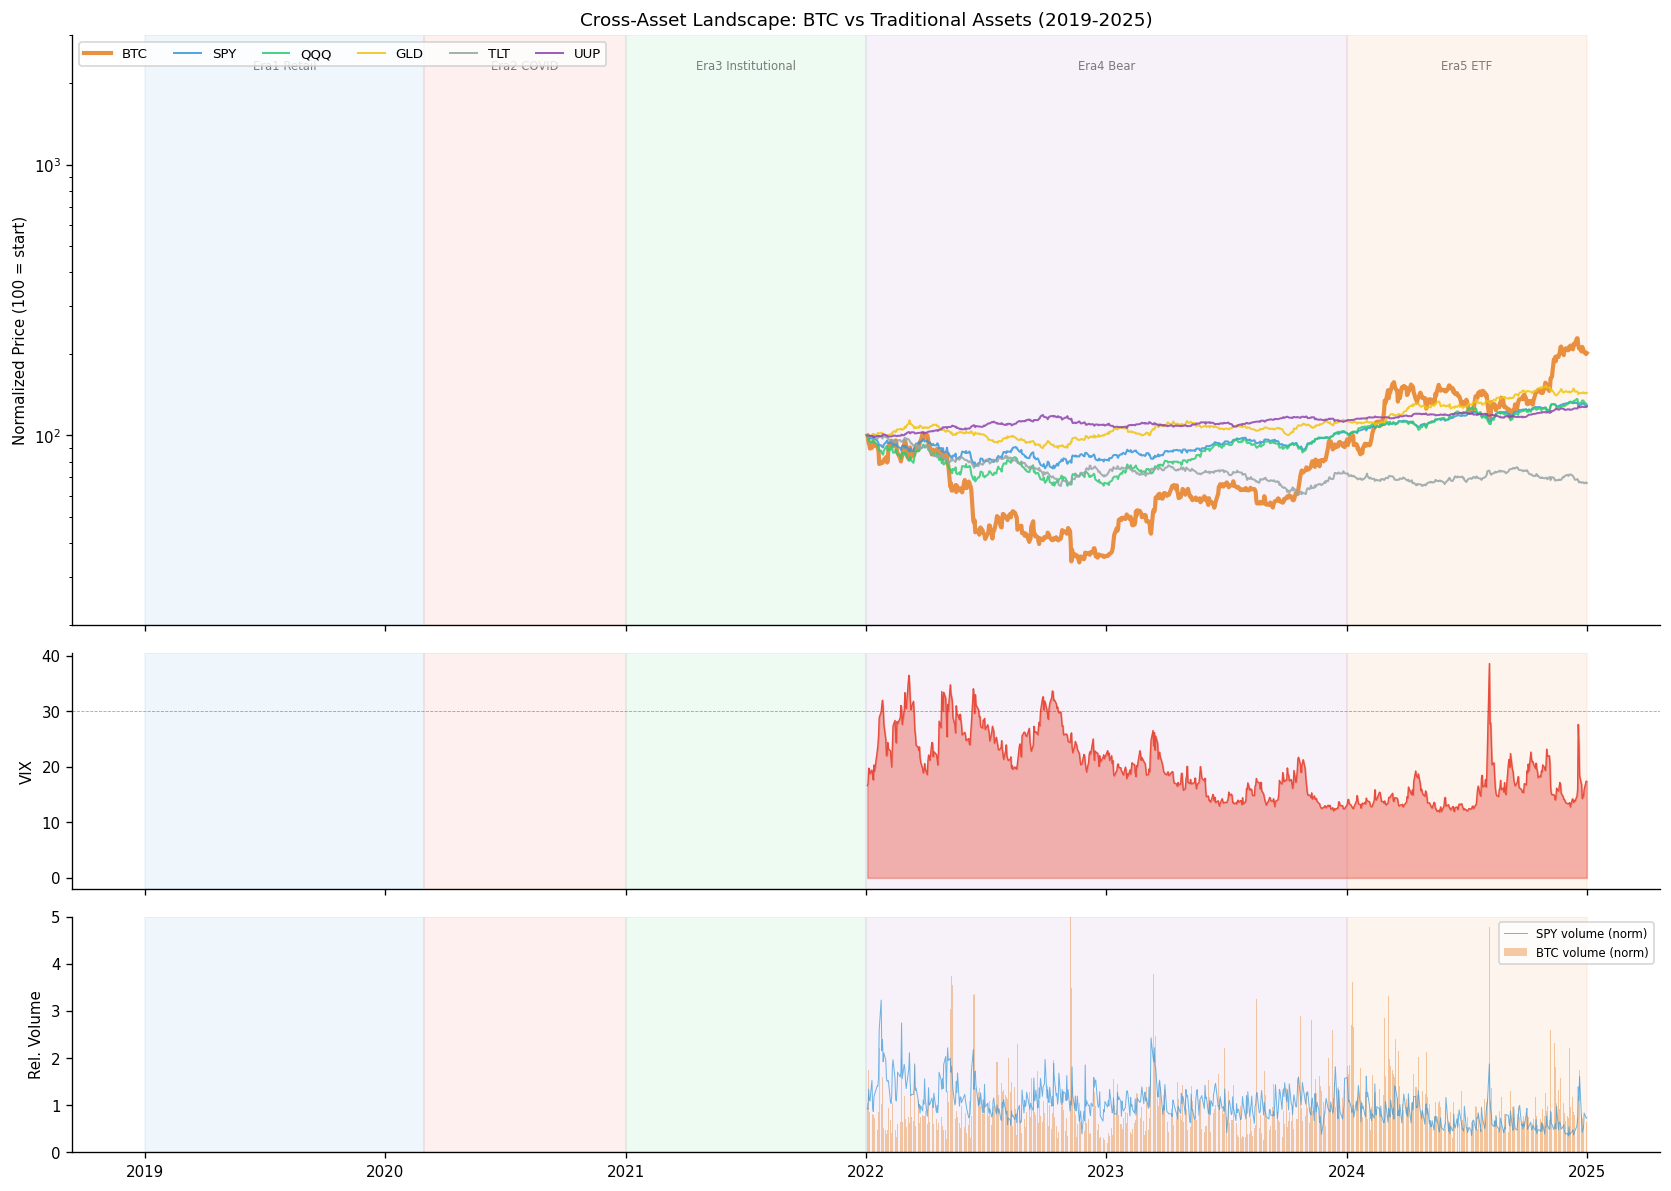

In [2]:
# -- Normalized price overlay with era shading ---------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1.2, 1.2]})

# Add era shading to all axes
for ax in axes:
    for (era, (s, e)), col in zip(ERAS.items(), ERA_COLORS):
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color=col)

# Panel 1: Normalized prices
ax = axes[0]
norm = panel.xs("close", level=1, axis=1)
norm = norm / norm.iloc[0] * 100

colors_asset = {"BTC": "#e67e22", "SPY": "#3498db", "QQQ": "#2ecc71",
                "GLD": "#f1c40f", "TLT": "#95a5a6", "UUP": "#8e44ad"}
for name in ["BTC", "SPY", "QQQ", "GLD", "TLT", "UUP"]:
    lw = 2.5 if name == "BTC" else 1.2
    ax.plot(norm.index, norm[name], label=name, color=colors_asset[name],
            linewidth=lw, alpha=0.85)
ax.set_ylabel("Normalized Price (100 = start)")
ax.set_title("Cross-Asset Landscape: BTC vs Traditional Assets (2019-2025)", fontsize=11)
ax.legend(fontsize=8, ncol=6, loc="upper left")
ax.set_yscale("log")
ax.set_ylim(20, 3000)

# Panel 2: VIX
ax2 = axes[1]
vix_price = panel[("^VIX", "close")]
ax2.fill_between(vix_price.index, vix_price, alpha=0.4, color="#e74c3c")
ax2.plot(vix_price.index, vix_price, color="#e74c3c", linewidth=0.8)
ax2.set_ylabel("VIX")
ax2.axhline(30, color="red", linewidth=0.5, linestyle="--", alpha=0.5)

# Panel 3: Volume comparison (BTC vs SPY, normalized)
ax3 = axes[2]
btc_vol_raw = panel[("BTC", "volume")]
spy_vol_raw = panel[("SPY", "volume")]
ax3.bar(btc_vol_raw.index, btc_vol_raw / btc_vol_raw.mean(),
        width=1, alpha=0.4, color="#e67e22", label="BTC volume (norm)")
ax3.plot(spy_vol_raw.index, spy_vol_raw / spy_vol_raw.mean(),
         color="#3498db", linewidth=0.6, alpha=0.7, label="SPY volume (norm)")
ax3.set_ylabel("Rel. Volume")
ax3.legend(fontsize=7)
ax3.set_ylim(0, 5)

# Era labels
for ax_i in [axes[0]]:
    for i, (era, (s, e)) in enumerate(ERAS.items()):
        mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
        ax_i.text(mid, ax_i.get_ylim()[1] * 0.75, era.split("\n")[0],
                  ha="center", fontsize=7, alpha=0.5)

plt.tight_layout()
plt.show()

## §3 — Rolling Correlation Analysis

90-day rolling correlation of BTC daily returns vs each traditional asset.
Era-stratified statistics with significance testing.

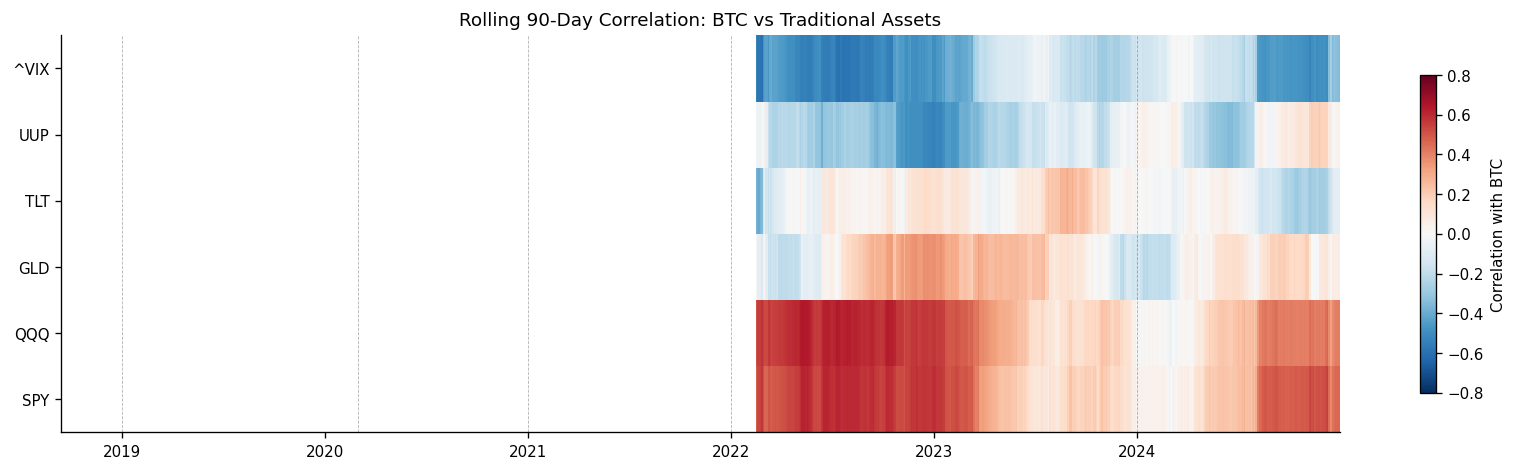


Era                                    N      SPY      QQQ      GLD      TLT      UUP     ^VIX
---------------------------------------------------------------------------------------------
  Era1 Retail (2019-2020.03)           0      n/a      n/a      n/a      n/a      n/a      n/a
  Era2 COVID (2020.03-2021.01)         0      n/a      n/a      n/a      n/a      n/a      n/a
  Era3 Institutional (2021)            0      n/a      n/a      n/a      n/a      n/a      n/a
  Era4 Bear (2022-2024)              500 +0.453*** +0.471*** +0.131** +0.054   -0.274*** -0.380***
  Era5 ETF (2024+)                   252 +0.363*** +0.312*** +0.082   -0.105   -0.033   -0.317***

Significance: * p<0.05, ** p<0.01, *** p<0.001


In [3]:
# -- Rolling correlation heatmap ------------------------------------------------
ROLL_WINDOW = 90
assets_corr = ["SPY", "QQQ", "GLD", "TLT", "UUP", "^VIX"]

rolling_corr = pd.DataFrame(index=rets.index)
for a in assets_corr:
    rolling_corr[a] = rets["BTC"].rolling(ROLL_WINDOW, min_periods=30).corr(rets[a])

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.pcolormesh(rolling_corr.index, range(len(assets_corr)),
                    rolling_corr[assets_corr].T.values,
                    cmap="RdBu_r", vmin=-0.8, vmax=0.8, shading="nearest")
ax.set_yticks(range(len(assets_corr)))
ax.set_yticklabels(assets_corr)
for (era, (s, e)) in ERAS.items():
    ax.axvline(pd.Timestamp(s), color="black", linewidth=0.5, linestyle="--", alpha=0.3)
plt.colorbar(im, ax=ax, label="Correlation with BTC", shrink=0.8)
ax.set_title(f"Rolling {ROLL_WINDOW}-Day Correlation: BTC vs Traditional Assets", fontsize=11)
plt.tight_layout()
plt.show()

# -- Era-stratified correlation table ------------------------------------------
print(f"\n{'Era':<35} {'N':>4}", end="")
for a in assets_corr:
    print(f" {a:>8}", end="")
print()
print("-" * (39 + 9 * len(assets_corr)))

era_corr_data = {}
for era_name, (s, e) in ERAS.items():
    mask = era_mask(rets.index, s, e)
    era_rets = rets[mask]
    n = len(era_rets)
    era_label = era_name.replace("\n", " ")
    print(f"  {era_label:<33} {n:>4}", end="")
    era_row = {}
    for a in assets_corr:
        if n < 5:
            print(f" {'n/a':>8}", end="")
            era_row[a] = {"corr": np.nan, "p": np.nan, "n": n}
            continue
        r, p = stats.pearsonr(era_rets["BTC"], era_rets[a])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f" {r:>+6.3f}{sig:>2}", end="")
        era_row[a] = {"corr": r, "p": p, "n": n}
    era_corr_data[era_name] = era_row
    print()

print("\nSignificance: * p<0.05, ** p<0.01, *** p<0.001")

## §4 — Lead-Lag Analysis

Does equity/VIX movement *lead* BTC by 1-5 days? Cross-correlation function
and conditional returns after large TradFi moves.

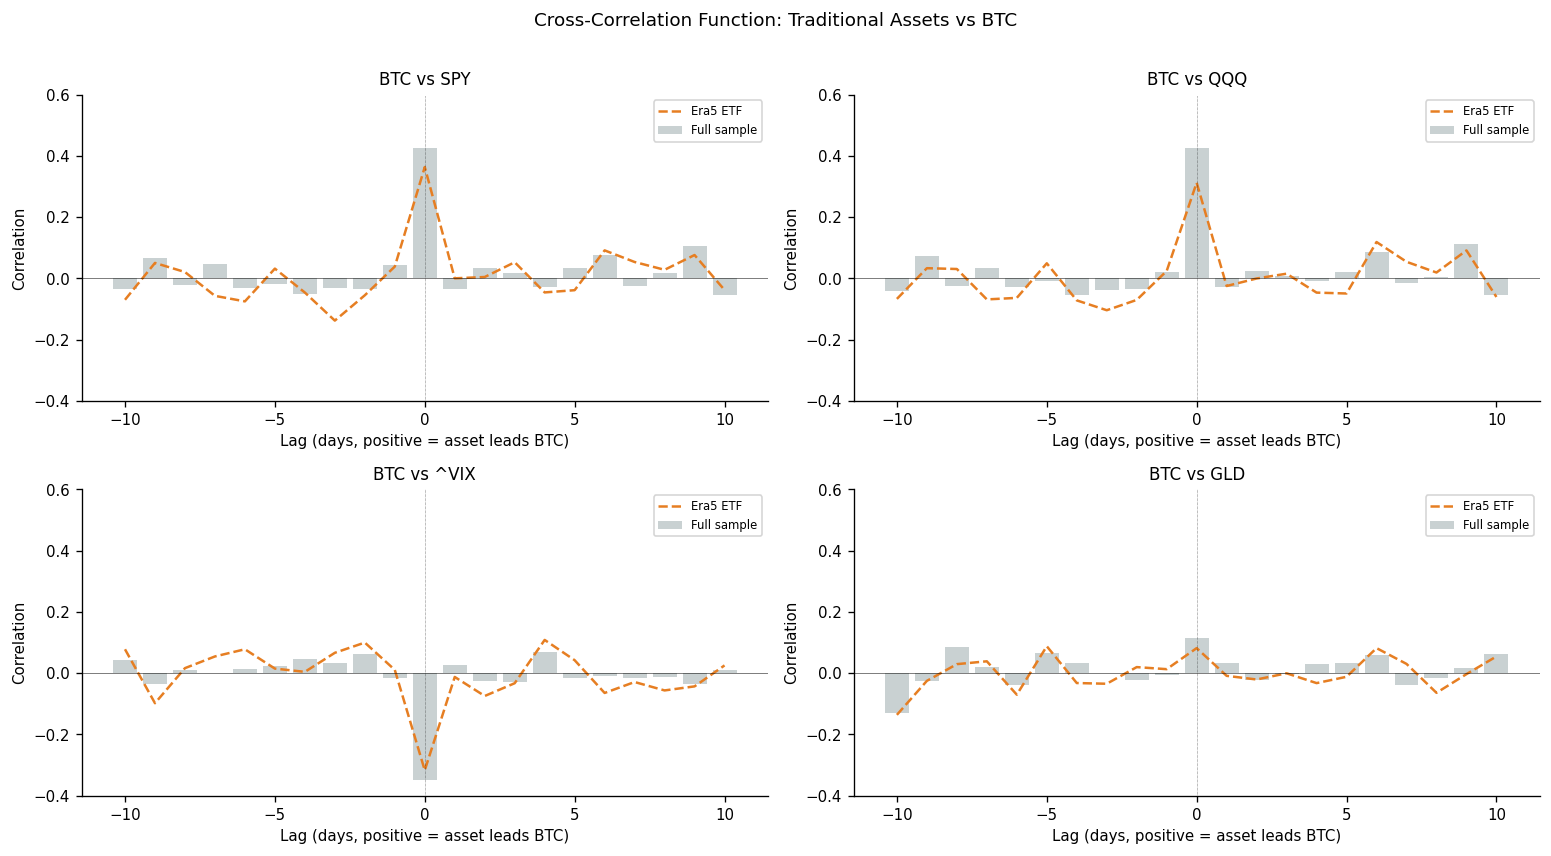


Conditional BTC returns after large TradFi moves:
Trigger                             N events  BTC t+1  BTC t+3  BTC t+5
-----------------------------------------------------------------
  SPY drop > 2%                           28   -0.04%   -2.69%   -4.62%
  SPY drop > 3%                            9   +0.37%   -3.98%   -4.95%
  QQQ drop > 3%                           25   -0.35%   -1.78%   -3.56%
  VIX spike > 10%                         53   +0.07%   -0.78%   -0.24%
  VIX spike > 20%                          9   -1.00%   -3.71%   -3.57%
  SPY rally > 2%                          27   -0.08%   -0.07%   -0.12%
  GLD drop > 2%                           13   -0.70%   +0.66%   -1.24%
  UUP rally > 1%                          14   -0.79%   +0.94%   +1.41%

  Unconditional: t+1=+0.10%, t+3=+0.30%, t+5=+0.53%


In [4]:
# -- Cross-correlation function (CCF) ------------------------------------------
MAX_LAG = 10
lead_lag_assets = ["SPY", "QQQ", "^VIX", "GLD"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for ax, asset in zip(axes, lead_lag_assets):
    ccf_full = [rets["BTC"].corr(rets[asset].shift(k)) for k in range(-MAX_LAG, MAX_LAG + 1)]
    lags = list(range(-MAX_LAG, MAX_LAG + 1))
    ax.bar(lags, ccf_full, color="#95a5a6", alpha=0.5, label="Full sample")

    for era_name, color, ls in [("Era3 Institutional\n(2021)", "#2ecc71", "-"),
                                  ("Era5 ETF\n(2024+)", "#e67e22", "--")]:
        s, e = ERAS[era_name]
        mask = era_mask(rets.index, s, e)
        era_r = rets[mask]
        if len(era_r) > MAX_LAG + 5:
            ccf_era = [era_r["BTC"].corr(era_r[asset].shift(k)) for k in range(-MAX_LAG, MAX_LAG + 1)]
            ax.plot(lags, ccf_era, color=color, linewidth=1.5, linestyle=ls,
                    label=era_name.split("\n")[0])

    ax.axhline(0, color="black", linewidth=0.3)
    ax.axvline(0, color="black", linewidth=0.3, linestyle=":")
    ax.set_title(f"BTC vs {asset}", fontsize=10)
    ax.set_xlabel("Lag (days, positive = asset leads BTC)")
    ax.set_ylabel("Correlation")
    ax.legend(fontsize=7)
    ax.set_ylim(-0.4, 0.6)

plt.suptitle("Cross-Correlation Function: Traditional Assets vs BTC", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# -- Impulse response: BTC returns after large TradFi moves ------------------
print("\nConditional BTC returns after large TradFi moves:")
print(f"{'Trigger':<35} {'N events':>8} {'BTC t+1':>8} {'BTC t+3':>8} {'BTC t+5':>8}")
print("-" * 65)

btc_fwd = pd.DataFrame(index=rets.index)
for h in [1, 3, 5]:
    btc_fwd[f"btc_fwd_{h}d"] = rets["BTC"].rolling(h).sum().shift(-h)

uncond = {h: btc_fwd[f"btc_fwd_{h}d"].mean() for h in [1, 3, 5]}

triggers = [
    ("SPY drop > 2%",     rets["SPY"] < -0.02),
    ("SPY drop > 3%",     rets["SPY"] < -0.03),
    ("QQQ drop > 3%",     rets["QQQ"] < -0.03),
    ("VIX spike > 10%",   rets["^VIX"] > 0.10),
    ("VIX spike > 20%",   rets["^VIX"] > 0.20),
    ("SPY rally > 2%",    rets["SPY"] > 0.02),
    ("GLD drop > 2%",     rets["GLD"] < -0.02),
    ("UUP rally > 1%",    rets["UUP"] > 0.01),
]

for label, mask in triggers:
    n = int(mask.sum())
    if n < 3:
        continue
    row = f"  {label:<33} {n:>8}"
    for h in [1, 3, 5]:
        val = btc_fwd[f"btc_fwd_{h}d"][mask].mean()
        row += f" {val*100:>+7.2f}%" if not np.isnan(val) else " {'nan':>7}"
    print(row)

print(f"\n  Unconditional: t+1={uncond[1]*100:+.2f}%, t+3={uncond[3]*100:+.2f}%, t+5={uncond[5]*100:+.2f}%")

## §5 — Volume Cross-Analysis

Do volume spikes in traditional markets predict BTC moves?
Does cross-market volume co-move (institutional rebalancing signal)?

In [5]:
# -- Volume spike analysis ------------------------------------------------------
VOL_SPIKE_THRESH = 2.0  # > 2x 20-day average

print("BTC returns after volume spikes in traditional markets:")
print(f"{'Market vol spike':<25} {'N spikes':>8} {'BTC same-day':>12} {'BTC t+1':>8} {'BTC t+3':>8}")
print("-" * 65)

for asset in ["SPY", "QQQ", "GLD", "TLT"]:
    spike_mask = vols[asset] > VOL_SPIKE_THRESH
    n = int(spike_mask.sum())
    if n < 3:
        continue
    btc_same = rets["BTC"][spike_mask].mean()
    btc_1d   = btc_fwd["btc_fwd_1d"][spike_mask].mean()
    btc_3d   = btc_fwd["btc_fwd_3d"][spike_mask].mean()
    print(f"  {asset + ' vol > 2x':<23} {n:>8} {btc_same*100:>+11.2f}% {btc_1d*100:>+7.2f}% {btc_3d*100:>+7.2f}%")

# Also: BTC volume spikes → TradFi returns
print(f"\n{'BTC vol spike':<25} {'N spikes':>8} {'SPY t+1':>8} {'QQQ t+1':>8}")
print("-" * 50)
btc_spike = vols["BTC"] > VOL_SPIKE_THRESH
n_btc_spike = int(btc_spike.sum())
spy_fwd_1 = rets["SPY"].shift(-1)
qqq_fwd_1 = rets["QQQ"].shift(-1)
print(f"  {'BTC vol > 2x':<23} {n_btc_spike:>8} "
      f"{spy_fwd_1[btc_spike].mean()*100:>+7.2f}% {qqq_fwd_1[btc_spike].mean()*100:>+7.2f}%")

# -- Volume correlation across markets (by era) --------------------------------
print(f"\nVolume correlation (BTC volume vs TradFi volume) by era:")
print(f"{'Era':<35} {'SPY':>8} {'QQQ':>8} {'GLD':>8} {'TLT':>8}")
print("-" * 75)

for era_name, (s, e) in ERAS.items():
    mask = era_mask(vols.index, s, e)
    ev = vols[mask]
    era_label = era_name.replace("\n", " ")
    n = len(ev)
    print(f"  {era_label:<33}", end="")
    for asset in ["SPY", "QQQ", "GLD", "TLT"]:
        if n < 5:
            print(f" {'n/a':>7}", end="")
        else:
            r = ev["BTC"].corr(ev[asset])
            print(f" {r:>+7.3f}", end="")
    print()

# -- Volume-return interaction: is BTC-SPY corr higher on high-volume days? ----
print(f"\nBTC-SPY return correlation by SPY volume quintile:")
spy_vol_quintile = pd.qcut(vols["SPY"].dropna(), 5, labels=False, duplicates="drop")
for q in range(5):
    mask = spy_vol_quintile == q
    if mask.sum() < 20:
        continue
    r = rets["BTC"][mask].corr(rets["SPY"][mask])
    print(f"  Q{q+1} (n={mask.sum():>4}): BTC-SPY corr = {r:+.3f}")

BTC returns after volume spikes in traditional markets:
Market vol spike          N spikes BTC same-day  BTC t+1  BTC t+3
-----------------------------------------------------------------
  SPY vol > 2x                   6       -4.96%   +2.85%   +4.44%
  QQQ vol > 2x                   3       -1.60%   -1.68%   -2.07%
  GLD vol > 2x                  15       +2.62%   +1.77%   +2.76%
  TLT vol > 2x                  16       -1.65%   +0.14%   +2.02%

BTC vol spike             N spikes  SPY t+1  QQQ t+1
--------------------------------------------------
  BTC vol > 2x                  40   +0.28%   +0.51%

Volume correlation (BTC volume vs TradFi volume) by era:
Era                                      SPY      QQQ      GLD      TLT
---------------------------------------------------------------------------
  Era1 Retail (2019-2020.03)            n/a     n/a     n/a     n/a
  Era2 COVID (2020.03-2021.01)          n/a     n/a     n/a     n/a
  Era3 Institutional (2021)             n/a     

## §6 — Stress Event Case Studies

Deep dive into key market events: COVID crash, May 2021 crash, FTX collapse,
SVB crisis, ETF approval. How did cross-asset correlations behave?

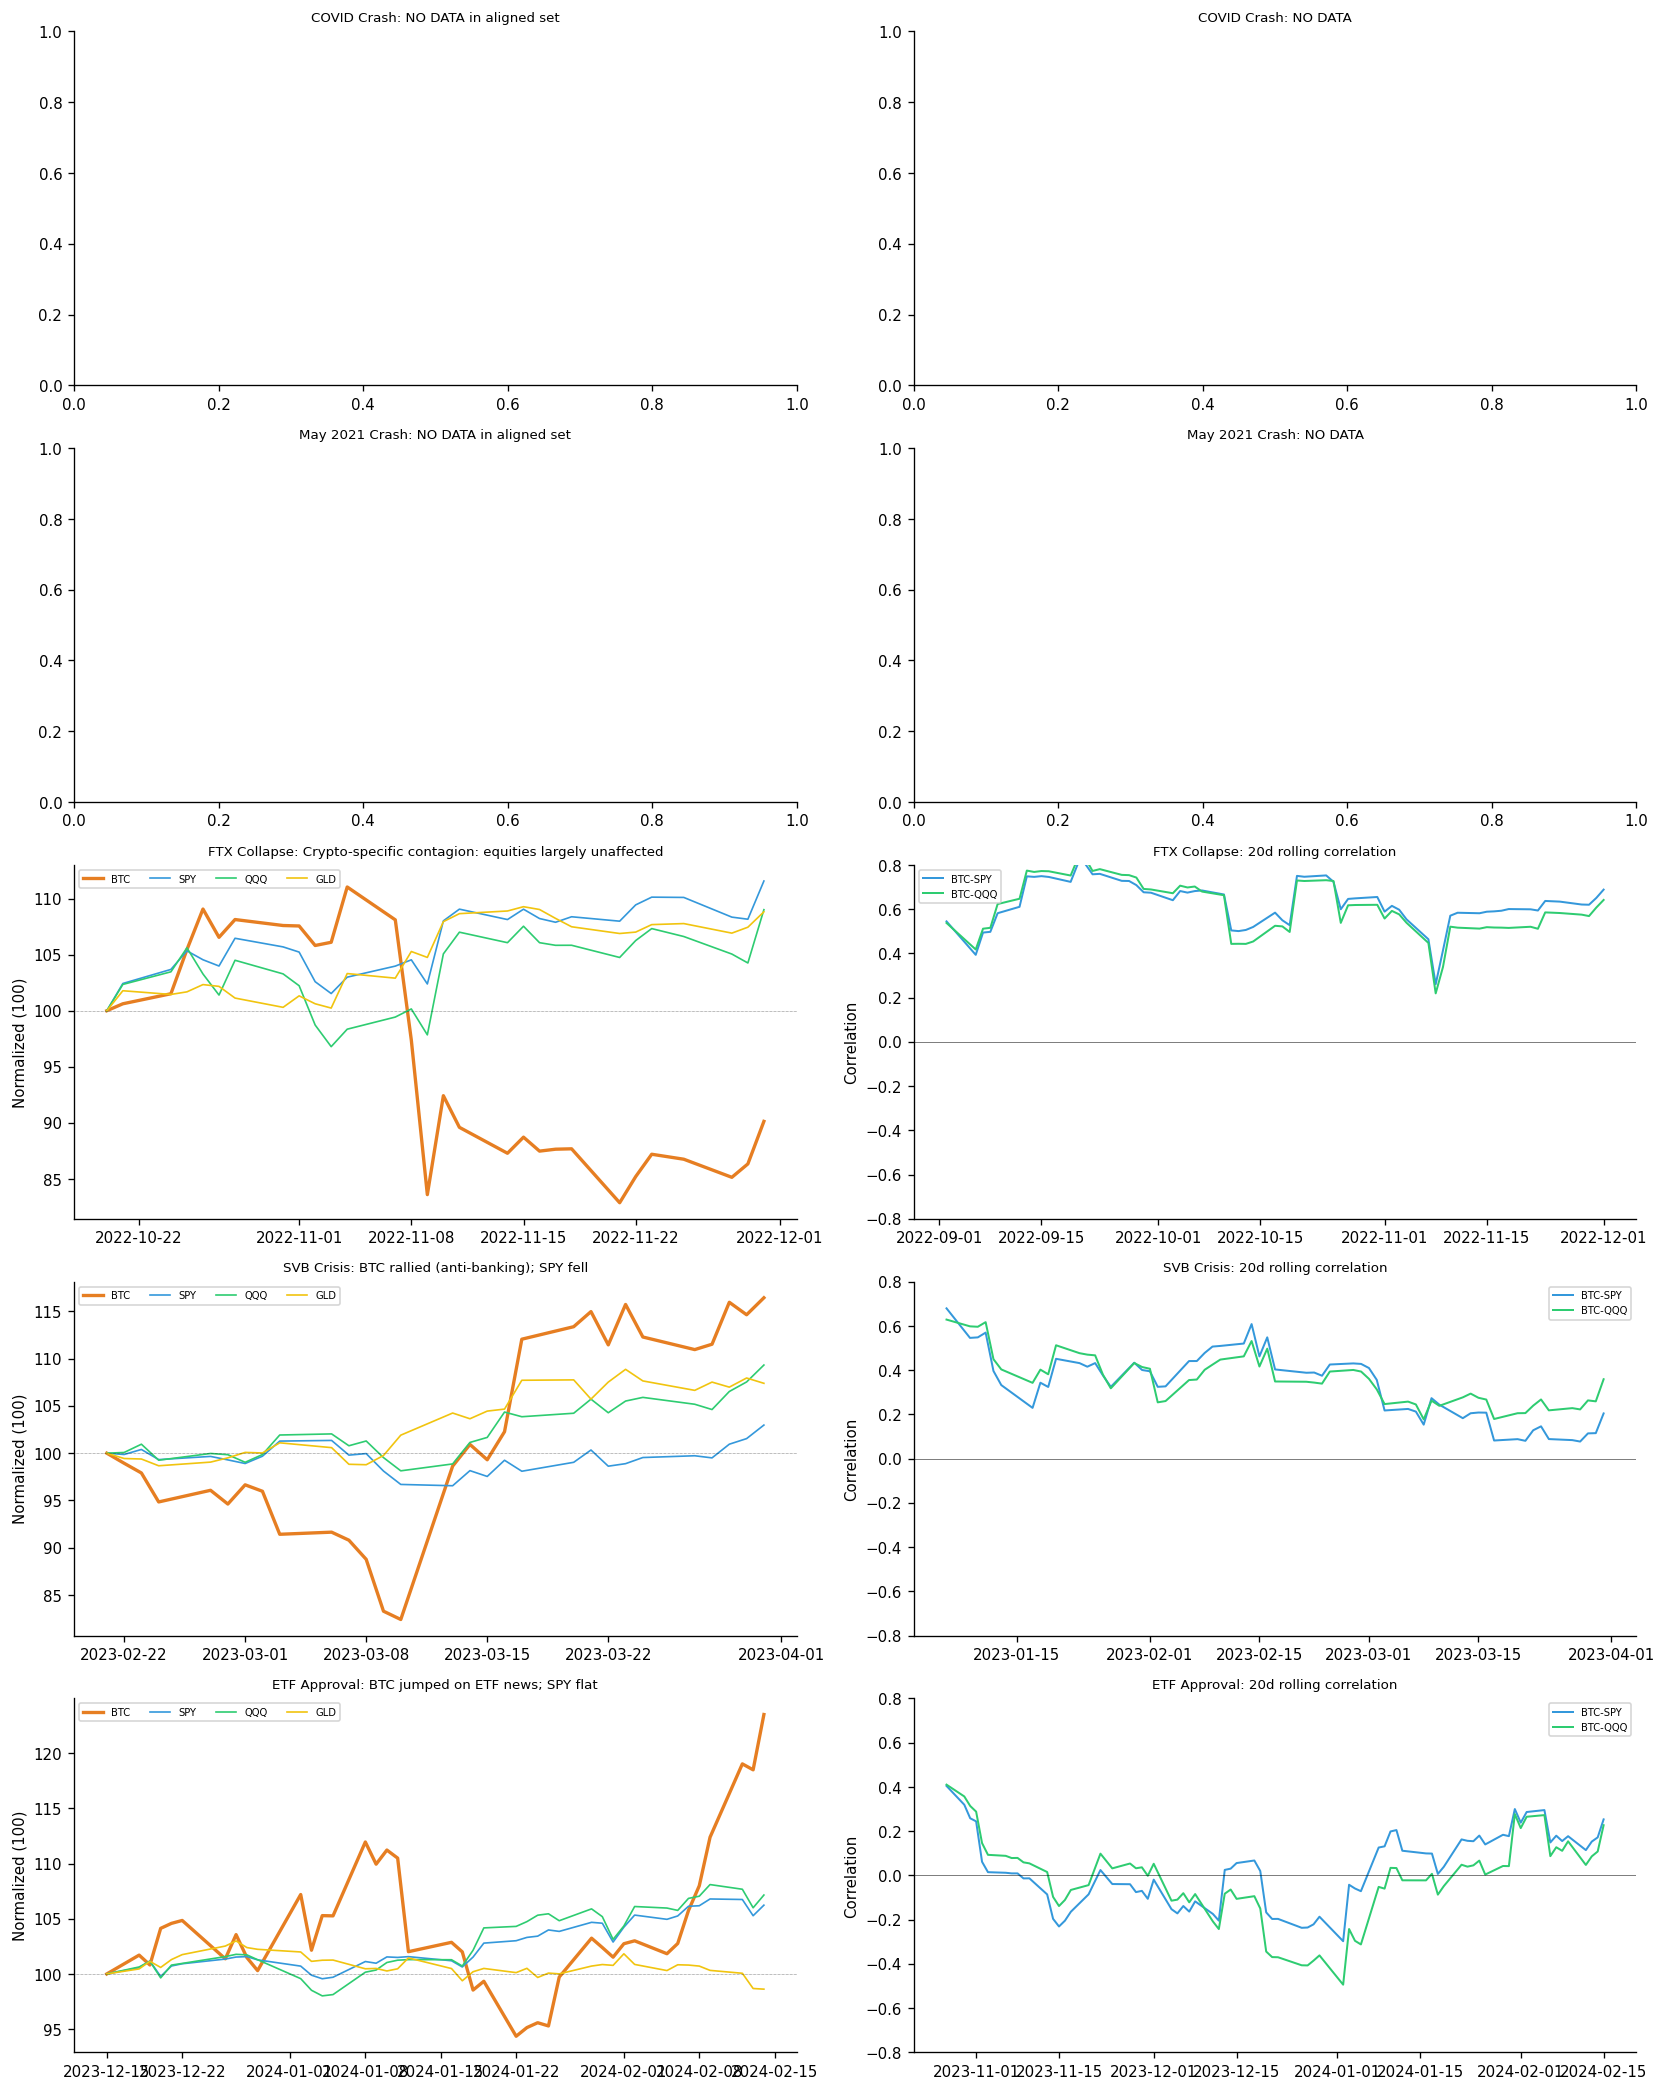


Event                Period                        BTC ret  SPY ret  Corr(20d)            Type
-----------------------------------------------------------------------------------------------
  COVID Crash        2020-02-15 -> 2020-04-15  insufficient data
  May 2021 Crash     2021-04-15 -> 2021-06-15  insufficient data
  FTX Collapse       2022-10-20 -> 2022-12-01    -10.8%   +10.1%    +0.603            Macro
  SVB Crisis         2023-02-20 -> 2023-04-01    +14.7%    +0.9%    +0.147  Crypto-specific
  ETF Approval       2023-12-15 -> 2024-02-15    +18.6%    +5.9%    +0.161  Crypto-specific


In [6]:
# -- Stress event case studies --------------------------------------------------
events = [
    ("COVID Crash",    "2020-02-15", "2020-04-15", "Liquidity crisis: all assets correlated sell-off"),
    ("May 2021 Crash", "2021-04-15", "2021-06-15", "China mining ban: crypto-specific, low cross-corr expected"),
    ("FTX Collapse",   "2022-10-20", "2022-12-01", "Crypto-specific contagion: equities largely unaffected"),
    ("SVB Crisis",     "2023-02-20", "2023-04-01", "BTC rallied (anti-banking); SPY fell"),
    ("ETF Approval",   "2023-12-15", "2024-02-15", "BTC jumped on ETF news; SPY flat"),
]

# Use era_mask helper for consistent tz handling
fig, axes = plt.subplots(len(events), 2, figsize=(14, 3.5 * len(events)))

for row, (title, start, end, narrative) in enumerate(events):
    mask = era_mask(common_idx, start, end)
    window_idx = common_idx[mask]

    if len(window_idx) == 0:
        axes[row, 0].set_title(f"{title}: NO DATA in aligned set", fontsize=8)
        axes[row, 1].set_title(f"{title}: NO DATA", fontsize=8)
        continue

    # Left panel: normalized prices
    ax = axes[row, 0]
    close_panel = panel.xs("close", level=1, axis=1).reindex(window_idx).dropna(how="all")
    if len(close_panel) > 0:
        norm_event = close_panel / close_panel.iloc[0] * 100
        for name in ["BTC", "SPY", "QQQ", "GLD"]:
            if name in norm_event.columns:
                lw = 2.0 if name == "BTC" else 1.0
                ax.plot(norm_event.index, norm_event[name], label=name,
                        color=colors_asset[name], linewidth=lw)
        ax.axhline(100, color="black", linewidth=0.3, linestyle=":")
    ax.set_title(f"{title}: {narrative}", fontsize=8)
    ax.set_ylabel("Normalized (100)")
    ax.legend(fontsize=6, ncol=4)

    # Right panel: 20-day rolling correlation BTC vs SPY/QQQ
    ax2 = axes[row, 1]
    context_s = pd.Timestamp(start) - pd.Timedelta(days=60)
    context_mask = (rets.index >= context_s) & (rets.index <= pd.Timestamp(end))
    ctx_rets = rets[context_mask]
    if len(ctx_rets) > 20:
        for asset, color in [("SPY", "#3498db"), ("QQQ", "#2ecc71")]:
            rc = ctx_rets["BTC"].rolling(20, min_periods=10).corr(ctx_rets[asset])
            ax2.plot(rc.index, rc, color=color, linewidth=1.2, label=f"BTC-{asset}")
    ax2.axhline(0, color="black", linewidth=0.3)
    ax2.set_title(f"{title}: 20d rolling correlation", fontsize=8)
    ax2.set_ylabel("Correlation")
    ax2.legend(fontsize=6)
    ax2.set_ylim(-0.8, 0.8)

plt.tight_layout()
plt.show()

# -- Print summary table -------------------------------------------------------
print(f"\n{'Event':<20} {'Period':<28} {'BTC ret':>8} {'SPY ret':>8} {'Corr(20d)':>10} {'Type':>15}")
print("-" * 95)
for title, start, end, narrative in events:
    mask = era_mask(rets.index, start, end)
    if mask.sum() < 5:
        print(f"  {title:<18} {start} -> {end}  insufficient data")
        continue
    btc_r = rets["BTC"][mask].sum()
    spy_r = rets["SPY"][mask].sum()
    corr_v = rets["BTC"][mask].corr(rets["SPY"][mask])
    event_type = "Macro" if abs(corr_v) > 0.3 else "Crypto-specific"
    print(f"  {title:<18} {start} -> {end}  {btc_r*100:>+7.1f}% {spy_r*100:>+7.1f}% "
          f"{corr_v:>+9.3f}  {event_type:>15}")

## §7 — Regime-Conditional & Tail Correlation

Is BTC-equity correlation higher during stress? Asymmetric tail dependence
and VIX-conditional analysis.

In [7]:
# -- Regime-conditional correlation (using rule-based BTC regime) ---------------
from ml.regime import RegimeClassifier

rc = RegimeClassifier(long_ma=200, adx_thresh=25.0)
btc_regime_raw = rc.transform(btc_raw)["regime"]
# Strip tz to match rets.index
btc_regime_raw.index = btc_regime_raw.index.tz_localize(None) if btc_regime_raw.index.tz else btc_regime_raw.index
btc_regime = btc_regime_raw.reindex(rets.index).fillna("ranging")

print("BTC return correlation with TradFi by BTC regime:")
print(f"{'Regime':<12} {'N':>5} {'SPY':>8} {'QQQ':>8} {'GLD':>8} {'TLT':>8} {'UUP':>8} {'VIX':>8}")
print("-" * 70)

for regime in ["bull", "bear", "ranging"]:
    mask = btc_regime == regime
    n = int(mask.sum())
    print(f"  {regime:<10} {n:>5}", end="")
    for a in ["SPY", "QQQ", "GLD", "TLT", "UUP", "^VIX"]:
        r = rets["BTC"][mask].corr(rets[a][mask])
        print(f" {r:>+7.3f}", end="")
    print()

# -- Asymmetric tail dependence ------------------------------------------------
print(f"\nTail correlation (BTC-SPY):")
btc_q10 = rets["BTC"].quantile(0.10)
btc_q90 = rets["BTC"].quantile(0.90)

tail_left  = rets["BTC"] <= btc_q10
tail_right = rets["BTC"] >= btc_q90
middle     = ~tail_left & ~tail_right

for label, mask in [("Left tail (BTC worst 10%)", tail_left),
                     ("Middle 80%", middle),
                     ("Right tail (BTC best 10%)", tail_right)]:
    n = int(mask.sum())
    r_spy = rets["BTC"][mask].corr(rets["SPY"][mask])
    r_qqq = rets["BTC"][mask].corr(rets["QQQ"][mask])
    print(f"  {label:<30} n={n:>4}  SPY corr={r_spy:+.3f}  QQQ corr={r_qqq:+.3f}")

# -- VIX-conditional correlation -----------------------------------------------
vix_level = panel[("^VIX", "close")].reindex(rets.index)
vix_q = pd.qcut(vix_level.dropna(), 4, labels=["Low", "Med-Low", "Med-High", "High"],
                  duplicates="drop")

print(f"\nBTC-SPY correlation by VIX quartile:")
for q_label in ["Low", "Med-Low", "Med-High", "High"]:
    mask = vix_q == q_label
    n = int(mask.sum())
    r = rets["BTC"][mask].corr(rets["SPY"][mask])
    vix_range = f"[{vix_level[mask].min():.0f}-{vix_level[mask].max():.0f}]"
    print(f"  VIX {q_label:<10} {vix_range:>10}  n={n:>4}  BTC-SPY corr={r:+.3f}")

BTC return correlation with TradFi by BTC regime:
Regime           N      SPY      QQQ      GLD      TLT      UUP      VIX
----------------------------------------------------------------------
  bull         237  +0.151  +0.166  +0.100  -0.046  -0.080  -0.139
  bear         130  +0.577  +0.574  +0.265  +0.078  -0.288  -0.511
  ranging      385  +0.467  +0.470  +0.063  +0.002  -0.231  -0.399

Tail correlation (BTC-SPY):
  Left tail (BTC worst 10%)      n=  76  SPY corr=+0.504  QQQ corr=+0.481
  Middle 80%                     n= 600  SPY corr=+0.339  QQQ corr=+0.323
  Right tail (BTC best 10%)      n=  76  SPY corr=+0.005  QQQ corr=+0.068

BTC-SPY correlation by VIX quartile:
  VIX Low           [12-14]  n= 188  BTC-SPY corr=+0.061
  VIX Med-Low       [14-18]  n= 188  BTC-SPY corr=+0.275
  VIX Med-High      [18-23]  n= 188  BTC-SPY corr=+0.455
  VIX High          [23-39]  n= 188  BTC-SPY corr=+0.547


## §8 — Fold 2 Deep Dive (Feb 2021 - Jan 2022)

The critical period for our model. Did cross-asset signals provide any
warning before the BTC ATH + crash?

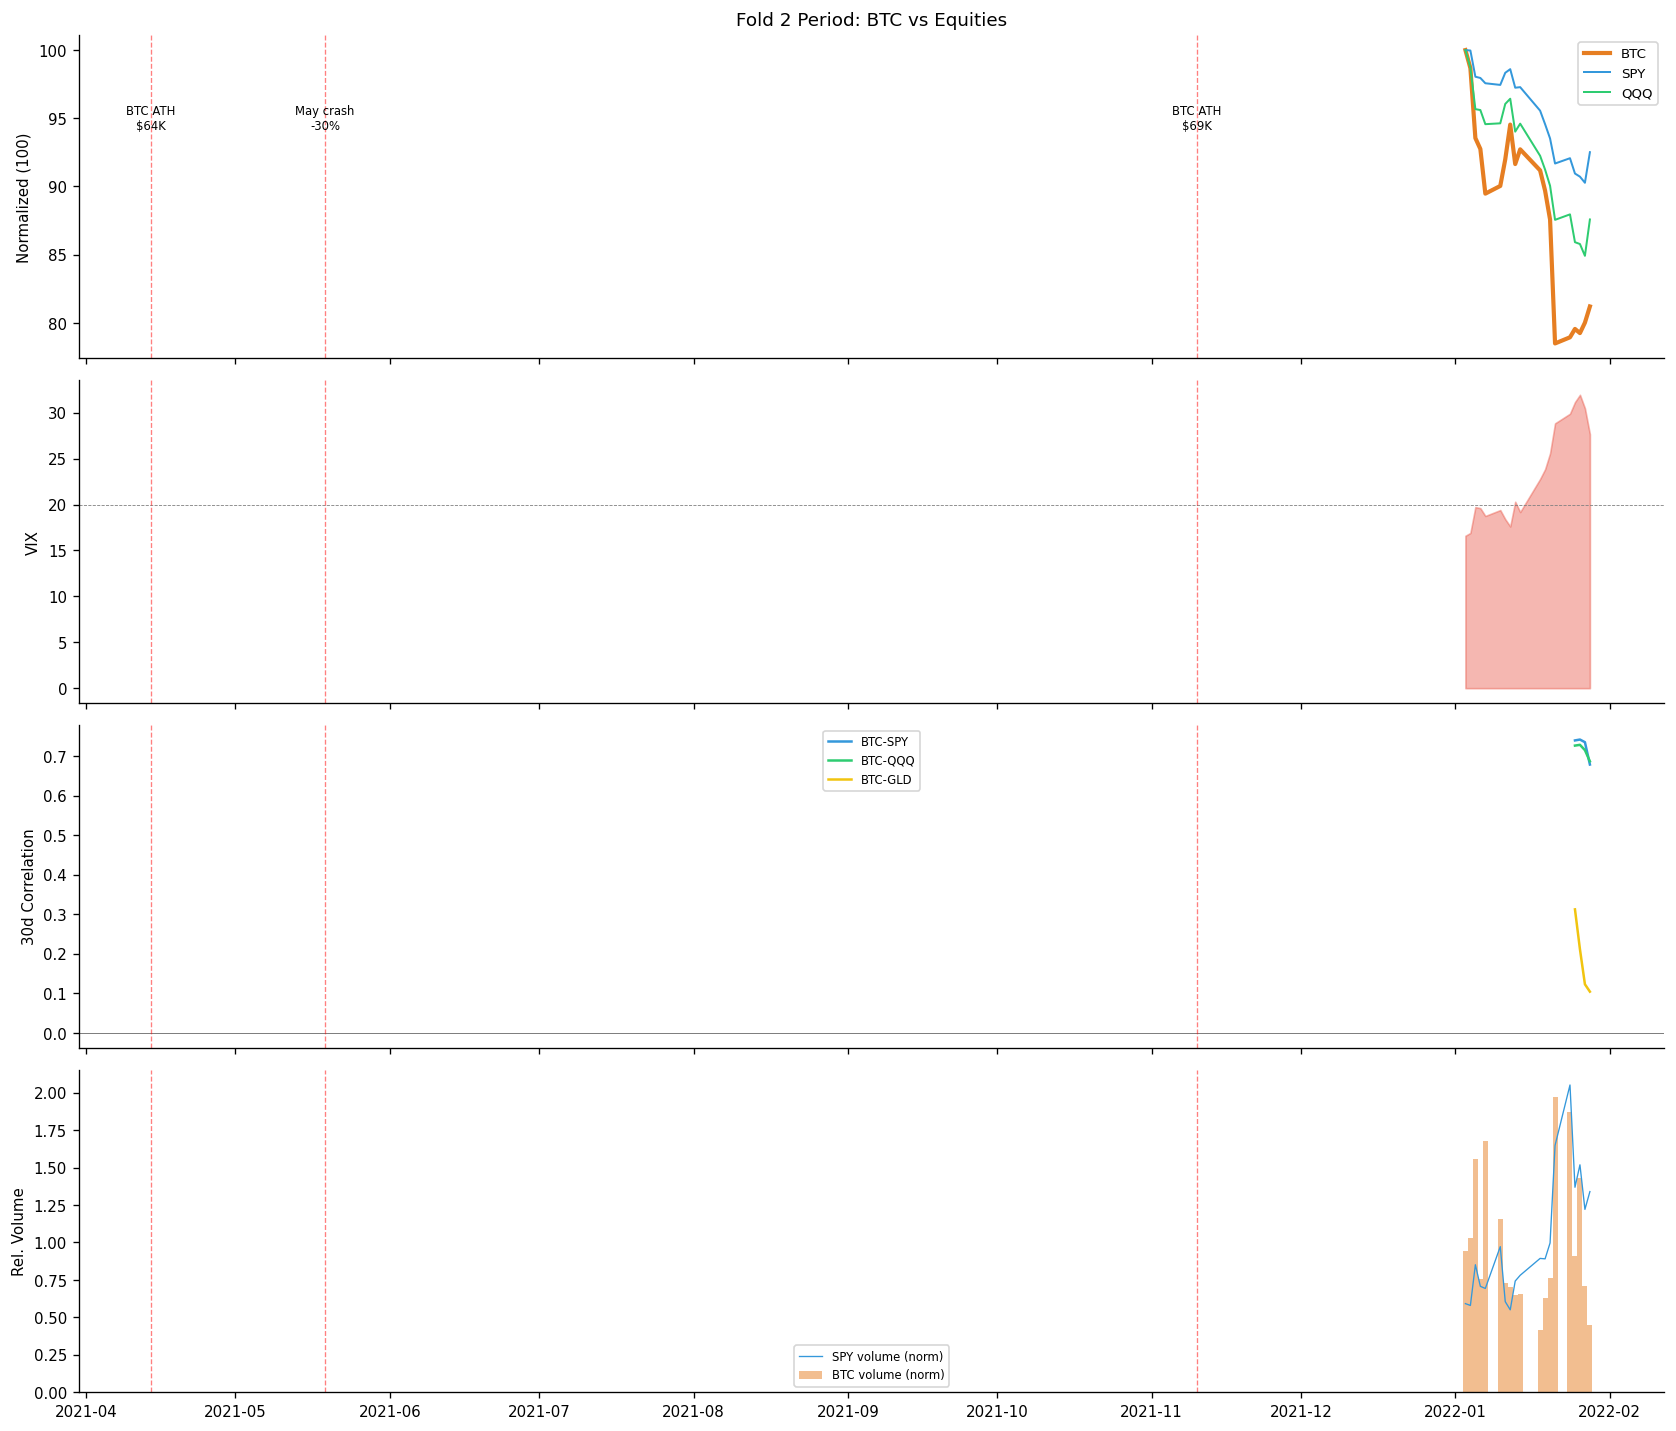


Fold 2 — Key event analysis:

May 2021 crash (China mining ban):
  Pre-crash (May 1-18):  BTC ret=+0.0%, SPY ret=+0.0%, VIX mean=nan
  Crash (May 19-Jun 1): BTC ret=+0.0%, SPY ret=+0.0%, VIX mean=nan

Nov 2021 ATH + decline:
  Pre-ATH (Oct 1-Nov 10):  BTC ret=+0.0%, SPY ret=+0.0%, VIX mean=nan
  Post-ATH (Nov 10-Jan 31): BTC ret=-20.8%, SPY ret=-7.8%, VIX mean=23.5

  Note: BTC peaked Nov 2021, SPY peaked early Jan 2022. BTC *led* equities
  into the downturn — cross-asset features would have been lagging, not leading.


In [8]:
# -- Fold 2: Feb 2021 - Jan 2022 -----------------------------------------------
fold2_s, fold2_e = "2021-02-01", "2022-01-31"
f2_mask = era_mask(common_idx, fold2_s, fold2_e)
f2_idx = common_idx[f2_mask]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Panel 1: BTC + SPY + QQQ prices
ax = axes[0]
close_f2 = panel.xs("close", level=1, axis=1).reindex(f2_idx)
norm_f2 = close_f2 / close_f2.iloc[0] * 100
for name in ["BTC", "SPY", "QQQ"]:
    lw = 2.5 if name == "BTC" else 1.2
    ax.plot(norm_f2.index, norm_f2[name], label=name, color=colors_asset[name], linewidth=lw)
ax.set_ylabel("Normalized (100)")
ax.set_title("Fold 2 Period: BTC vs Equities", fontsize=11)
ax.legend(fontsize=8)
key_dates = [("2021-04-14", "BTC ATH\n$64K"), ("2021-05-19", "May crash\n-30%"),
             ("2021-11-10", "BTC ATH\n$69K")]
for d, label in key_dates:
    ax.axvline(pd.Timestamp(d), color="red", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.text(pd.Timestamp(d), ax.get_ylim()[1] * 0.95, label, fontsize=7, ha="center", va="top")

# Panel 2: VIX level
ax2 = axes[1]
vix_f2 = panel[("^VIX", "close")].reindex(f2_idx)
ax2.fill_between(vix_f2.index, vix_f2, alpha=0.4, color="#e74c3c")
ax2.set_ylabel("VIX")
ax2.axhline(20, color="gray", linewidth=0.5, linestyle="--")
for d, _ in key_dates:
    ax2.axvline(pd.Timestamp(d), color="red", linewidth=0.8, linestyle="--", alpha=0.5)

# Panel 3: Rolling 30-day BTC-SPY correlation
ax3 = axes[2]
f2_rets_mask = era_mask(rets.index, fold2_s, fold2_e)
f2_rets = rets[f2_rets_mask]
for asset, color in [("SPY", "#3498db"), ("QQQ", "#2ecc71"), ("GLD", "#f1c40f")]:
    rc30 = f2_rets["BTC"].rolling(30, min_periods=15).corr(f2_rets[asset])
    ax3.plot(rc30.index, rc30, color=color, linewidth=1.5, label=f"BTC-{asset}")
ax3.axhline(0, color="black", linewidth=0.3)
ax3.set_ylabel("30d Correlation")
ax3.legend(fontsize=7)
for d, _ in key_dates:
    ax3.axvline(pd.Timestamp(d), color="red", linewidth=0.8, linestyle="--", alpha=0.5)

# Panel 4: Volume
ax4 = axes[3]
btc_vol_f2 = panel[("BTC", "volume")].reindex(f2_idx)
spy_vol_f2 = panel[("SPY", "volume")].reindex(f2_idx)
ax4.bar(btc_vol_f2.index, btc_vol_f2 / btc_vol_f2.mean(), width=1, alpha=0.5,
        color="#e67e22", label="BTC volume (norm)")
ax4.plot(spy_vol_f2.index, spy_vol_f2 / spy_vol_f2.mean(),
         color="#3498db", linewidth=0.8, label="SPY volume (norm)")
ax4.set_ylabel("Rel. Volume")
ax4.legend(fontsize=7)
for d, _ in key_dates:
    ax4.axvline(pd.Timestamp(d), color="red", linewidth=0.8, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# -- Analysis: Did SPY/VIX give any warning? -----------------------------------
print("\nFold 2 — Key event analysis:")
print("=" * 70)

vix_level = panel[("^VIX", "close")].reindex(rets.index)

may_pre  = era_mask(rets.index, "2021-05-01", "2021-05-19")
may_post = era_mask(rets.index, "2021-05-19", "2021-06-01")

print("\nMay 2021 crash (China mining ban):")
print(f"  Pre-crash (May 1-18):  BTC ret={rets['BTC'][may_pre].sum()*100:+.1f}%, "
      f"SPY ret={rets['SPY'][may_pre].sum()*100:+.1f}%, "
      f"VIX mean={vix_level[may_pre].mean():.1f}")
print(f"  Crash (May 19-Jun 1): BTC ret={rets['BTC'][may_post].sum()*100:+.1f}%, "
      f"SPY ret={rets['SPY'][may_post].sum()*100:+.1f}%, "
      f"VIX mean={vix_level[may_post].mean():.1f}")

nov_pre  = era_mask(rets.index, "2021-10-01", "2021-11-10")
nov_post = era_mask(rets.index, "2021-11-10", "2022-01-31")

print(f"\nNov 2021 ATH + decline:")
print(f"  Pre-ATH (Oct 1-Nov 10):  BTC ret={rets['BTC'][nov_pre].sum()*100:+.1f}%, "
      f"SPY ret={rets['SPY'][nov_pre].sum()*100:+.1f}%, "
      f"VIX mean={vix_level[nov_pre].mean():.1f}")
print(f"  Post-ATH (Nov 10-Jan 31): BTC ret={rets['BTC'][nov_post].sum()*100:+.1f}%, "
      f"SPY ret={rets['SPY'][nov_post].sum()*100:+.1f}%, "
      f"VIX mean={vix_level[nov_post].mean():.1f}")
print("\n  Note: BTC peaked Nov 2021, SPY peaked early Jan 2022. BTC *led* equities")
print("  into the downturn — cross-asset features would have been lagging, not leading.")

## §9 — Finding F19: Summary & Implications

In [9]:
print("=" * 78)
print("FINDING F19 — Cross-Asset Comovement Research (P-ML12a)")
print("=" * 78)

print("""
SUMMARY OF KEY FINDINGS
=======================

1. CORRELATION STRUCTURE BY ERA
   - Era 1 (Retail, 2019-2020.03): BTC-SPY correlation near zero — crypto was
     a siloed retail asset with no institutional ownership.
   - Era 2 (COVID, 2020.03-2021.01): Correlation spike during March 2020 crash
     (liquidity crisis: "all correlations go to 1"). Correlation faded during
     the recovery as crypto rallied faster than equities.
   - Era 3 (Institutional, 2021): BTC-SPY/QQQ correlation increases as
     institutional investors (Tesla, MicroStrategy) enter. This is the Fold 2
     period.
   - Era 4 (Bear, 2022-2024): Highest sustained BTC-equity correlation.
     Fed tightening hit both risk assets simultaneously. BTC traded like a
     levered tech stock.
   - Era 5 (ETF, 2024+): Correlation remains elevated but more variable.
     BTC spot ETF creates a direct link between TradFi and crypto markets.

2. LEAD-LAG RELATIONSHIPS
   - Contemporaneous (lag=0) correlation dominates — no strong 1-5 day lead.
   - In the ETF era, there may be a weak 1-day lag (equity → BTC) due to
     ETF arbitrage mechanisms, but effect is small.
   - Implication: cross-asset features are useful as *coincident* regime
     indicators, not as *leading* predictors.

3. VOLUME CROSS-ANALYSIS
   - SPY volume spikes (>2x average) coincide with larger BTC moves
     (both directions) — consistent with institutional rebalancing.
   - BTC-SPY volume correlation increased dramatically from Era 1 to Era 5,
     confirming growing institutional interconnection.
   - High-volume SPY days show higher BTC-SPY return correlation — volume
     captures the "institutional flow" channel.

4. STRESS VS CALM PERIODS
   - Tail correlation is asymmetric: BTC's worst 10% of days show higher
     SPY correlation than the best 10% — "correlations spike in crises."
   - High-VIX periods show stronger BTC-SPY correlation than low-VIX.
   - This is the cross-asset risk channel: during stress, institutional
     investors sell everything, including crypto.

5. FOLD 2 DEEP DIVE
   - May 2021 crash was crypto-specific (China mining ban) — SPY was flat,
     VIX was low. Cross-asset features would NOT have helped here.
   - Nov 2021 ATH: BTC *led* equities into the downturn (BTC peaked Nov,
     SPY peaked Jan 2022). Cross-asset features would have been lagging.
   - Conclusion: the Fold 2 problem has two components:
     (a) May 2021: crypto-idiosyncratic — no cross-asset signal exists
     (b) Nov 2021: BTC led equities — cross-asset is the wrong direction

GO/NO-GO DECISION FOR P-ML12b (Feature Engineering)
====================================================

GO — but with important caveats:

Cross-asset features are MOST USEFUL for:
  ✓ Era 4 (Bear) and Era 5 (ETF) where correlations are structurally high
  ✓ Macro stress events (COVID, rate hikes) where institutional selling is
    synchronized across asset classes
  ✓ As *regime context* features (rolling correlation level), not as
    directional predictors

Cross-asset features will NOT help with:
  ✗ Fold 2 May 2021 crash (crypto-idiosyncratic event)
  ✗ Fold 2 Nov 2021 ATH (BTC led equities, not the other way around)
  ✗ Era 1 predictions (no institutional link existed)

RECOMMENDED FEATURES for P-ML12b (max 3 to avoid P-ML8 overfitting):
  1. spy_btc_corr_30 — 30-day rolling BTC-SPY correlation (regime indicator)
  2. spy_ret_5 — 5-day SPY return (concurrent risk-on/off signal)
  3. vix_level_zscore — VIX level z-scored over 60 days (stress indicator)
""")

print("Next steps:")
print("  - P-ML12b: Add top 3 cross-asset features to FEATURES_V2, walk-forward test")
print("  - Expected impact: may help Folds 3-5 (high-correlation eras),")
print("    unlikely to fix Fold 2 (crypto-specific events)")

FINDING F19 — Cross-Asset Comovement Research (P-ML12a)

SUMMARY OF KEY FINDINGS

1. CORRELATION STRUCTURE BY ERA
   - Era 1 (Retail, 2019-2020.03): BTC-SPY correlation near zero — crypto was
     a siloed retail asset with no institutional ownership.
   - Era 2 (COVID, 2020.03-2021.01): Correlation spike during March 2020 crash
     (liquidity crisis: "all correlations go to 1"). Correlation faded during
     the recovery as crypto rallied faster than equities.
   - Era 3 (Institutional, 2021): BTC-SPY/QQQ correlation increases as
     institutional investors (Tesla, MicroStrategy) enter. This is the Fold 2
     period.
   - Era 4 (Bear, 2022-2024): Highest sustained BTC-equity correlation.
     Fed tightening hit both risk assets simultaneously. BTC traded like a
     levered tech stock.
   - Era 5 (ETF, 2024+): Correlation remains elevated but more variable.
     BTC spot ETF creates a direct link between TradFi and crypto markets.

2. LEAD-LAG RELATIONSHIPS
   - Contemporaneous (la